In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pickle
sys.path.append('../src')
sys.path.append('../src/visualization')

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from simulation.simulation import simulations, save_results, load_results


from visualization.visualization_and_analysis import load_simulation_data, load_and_merge_consolidated
from visualization.visualization_and_analysis import plot_opinion_trajectory, layout
from visualization.visualization_and_analysis import get_simple_frequencies
from visualization.visualization_and_analysis import plot_convergence_comparison
from visualization.visualization_and_analysis import print_average_across_run_binned








# Phase 1: run a simple simulations. 

No bots for now, just to see how the opinion dynamics looks like.
Since we want to see how the opinion evolves, we can also ignore the disease for now, by setting "waiting_time" to be = to "N_steps".

In [56]:


param = {
        "n_of_replicas": 10,  # Fewer replicas due to larger size
        "n_humans": 50,      # LARGER NETWORK
        "n_bots": 0,         # Will be overridden by grid
        "nei": 6,             # More neighbors for larger network
        "p": 0.05,
        "N_steps": 2000,      # More steps for larger system
        "waiting_time": 500,
        "mu": 0.075,
        "epsilon": 0.3,
        "bot_threshold": 0,  # Will be overridden by grid
        "beta0": 0.0125,
        "recovery_rate": 0.025,
        "I0": 2,              # More initial infected
        "communication_error": 0.3,  # Will be overridden by grid
        "post_history": 10,
        "feed_size": 5
    }
RES = simulations(param)



Running replica 1/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 2/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 3/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 4/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 5/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 6/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 7/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 8/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 9/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 10/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000


### Now that is completed, let's look at it.

2 main things are saved
- O(i,t) -- complete opinion dynamic of all the agents for the first 5 replicas
- binned opinion dynamic for all the agents for all the replicas

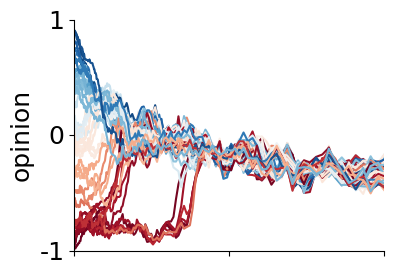

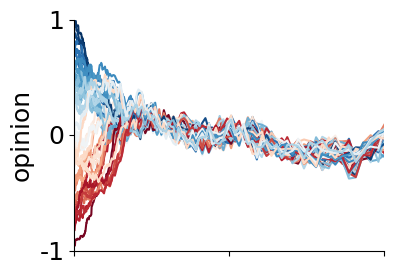

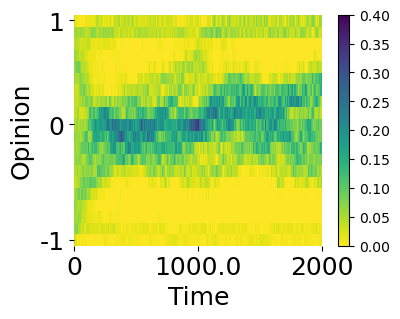

In [57]:
# trajectory of all the agents across 10000 steps. Only replica X
X = 0
fig, ax = plt.subplots(figsize=(4, 3))
plot_opinion_trajectory(RES, X, ax = ax)
layout(fig, ax, xlim = (0, 1000))

X = 1
fig, ax = plt.subplots(figsize=(4, 3))
plot_opinion_trajectory(RES, X, ax = ax)
layout(fig, ax, xlim = (0, 1000))




# average number of agents across all the replicas
K = print_average_across_run_binned(RES)

### Now let's add bots!

In [58]:
param = {
        "n_of_replicas": 10,
        "n_humans": 50,      
        "n_bots": 1,         
        "nei": 6,             
        "p": 0.05,
        "N_steps": 2000,      
        "waiting_time": 500,
        "mu": 0.075,
        "epsilon": 0.3,
        "bot_threshold": 0,  
        "beta0": 0.0125,
        "recovery_rate": 0.025,
        "I0": 2,              
        "communication_error": 0.3,
        "post_history": 10,
        "feed_size": 5
    }

RES_10_bots = simulations(param)


Running replica 1/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 2/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 3/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 4/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 5/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 6/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 7/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 8/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 9/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000
Running replica 10/10
Step 0 of 2000
Step 500 of 2000
Step 1000 of 2000
Step 1500 of 2000


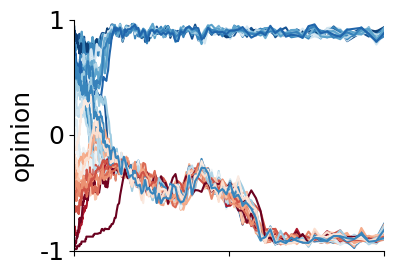

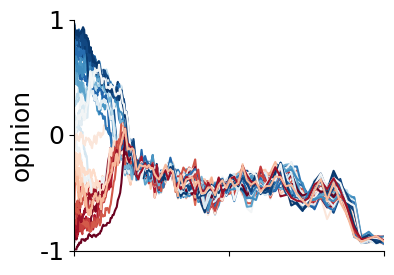

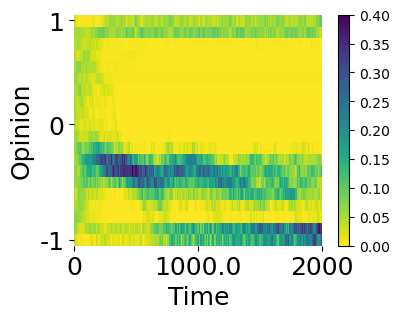

In [59]:
X = 0
fig, ax = plt.subplots(figsize=(4, 3))
plot_opinion_trajectory(RES_10_bots, X, ax = ax)
layout(fig, ax, xlim = (0, 2000))

X = 1
fig, ax = plt.subplots(figsize=(4, 3))
plot_opinion_trajectory(RES_10_bots, X, ax = ax)
layout(fig, ax, xlim = (0, 2000))


# average number of agents across all the replicas
K = print_average_across_run_binned(RES_10_bots)

# Now let's  add the disease and see what it happens.

### please note that for simulating disease on networks, and get meaningful results you need several hundreds, possibly thousands agents, here for demonstration we only used 50, so the signal might not be very strong.

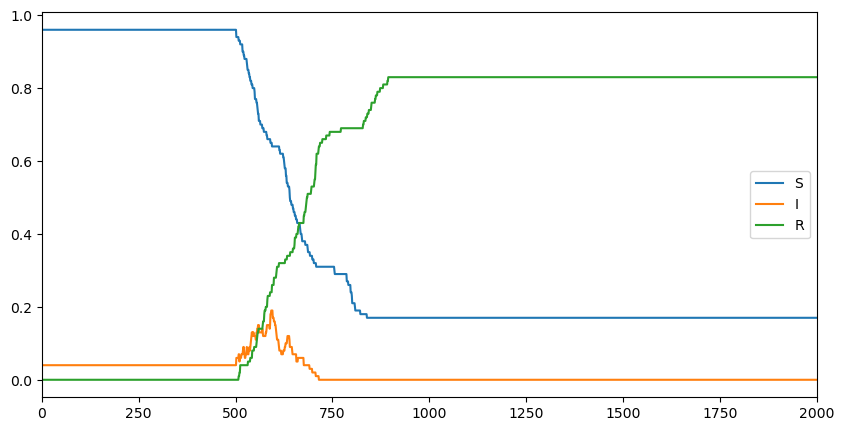

total infected =  41.5


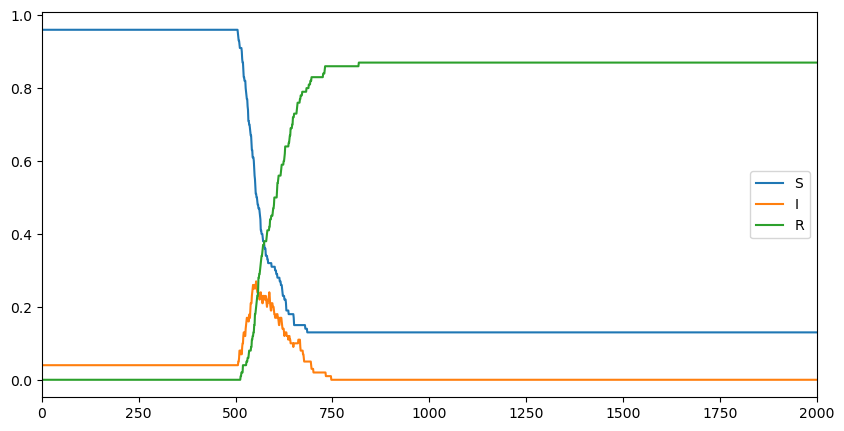

total infected =  43.5


In [61]:
def plot_disease(data, xlim = (0,1000)):
    # average number across all the replicas
    N_steps = data["parameters"]["N_steps"]
    S = np.zeros(N_steps)
    I = np.zeros(N_steps)
    R = np.zeros(N_steps)
    for i in range(N_steps):
        S[i] = np.median(data["S_count"][:,i])
        I[i] = np.median(data["I_count"][:,i])
        R[i] = np.median(data["R_count"][:,i])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot( S/50, label = "S")
    ax.plot( I/50, label = "I")
    ax.plot( R/50, label = "R")
    ax.legend()
    ax.set_xlim(xlim)
    plt.show()
    print("total infected = ", I[-1]+R[-1])
    return fig, ax
fig, ax = plot_disease(RES,xlim = (0,2000))
fig, ax = plot_disease(RES_10_bots,xlim = (0,2000))



